# GLA AIML HW - WEEK 1

## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading Dataset

In [ ]:
df = pd.read_csv('/content/ecommerce_500k.csv')

## Phase 1
The manager says "audit the data first." Where do you even begin?

EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_id                 500000 non-null  int64  
 1   customer_id              500000 non-null  int64  
 2   product_id               500000 non-null  int64  
 3   order_date               500000 non-null  object 
 4   category                 500000 non-null  object 
 5   sub_category             500000 non-null  object 
 6   product_base_price       500000 non-null  float64
 7   discount_percentage      500000 non-null  int64  
 8   final_price              500000 non-null  float64
 9   quantity                 500000 non-null  int64  
 10  total_amount             500000 non-null  float64
 11  shipping_cost            484934 non-null  float64
 12  shipping_method          500000 non-null  object 
 13  days_to_deliver          484751 non-null  float64
 14  paym

In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
product_id,0
order_date,0
category,0
sub_category,0
product_base_price,0
discount_percentage,0
final_price,0
quantity,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,order_id,customer_id,product_id,product_base_price,discount_percentage,final_price,quantity,total_amount,shipping_cost,days_to_deliver,rating,num_reviews,customer_age,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,is_cancelled
count,5.000000e+05,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,484934.000000,484751.000000,485010.000000,500000.000000,485072.000000,500000.000000,484996.000000,485275.000000,485186.000000,500000.000000,500000.000000,500000.000000
mean,1.250000e+06,55007.627196,2503.810058,84.833241,14.599090,72.438608,2.284080,165.605507,34.031570,4.238345,3.796253,27.015930,34.953966,0.278630,850.516871,8.511644,25.054783,9.999486,0.119808,0.061662
std,1.443377e+05,25995.094710,1441.201322,79.984198,12.943309,69.900582,1.739378,237.412198,39.185919,2.398417,0.943732,16.425337,11.132444,0.448325,799.762647,8.035044,14.142187,5.475479,0.324737,0.240541
min,1.000001e+06,10000.000000,1.000000,5.000000,0.000000,2.500000,1.000000,2.500000,0.000000,1.000000,1.000000,0.000000,18.000000,0.000000,50.000000,0.500000,1.000000,1.000000,0.000000,0.000000
25%,1.125001e+06,32490.000000,1259.000000,28.040000,0.000000,23.440000,1.000000,37.710000,4.540000,3.000000,3.500000,15.000000,26.000000,0.000000,280.180000,2.800000,13.000000,5.000000,0.000000,0.000000
50%,1.250000e+06,55056.500000,2503.000000,60.220000,15.000000,50.590000,2.000000,87.700000,24.890000,4.000000,4.000000,24.000000,35.000000,0.000000,604.170000,6.100000,25.000000,10.000000,0.000000,0.000000
75%,1.375000e+06,77510.000000,3752.000000,115.580000,20.000000,98.110000,3.000000,194.070000,44.020000,5.000000,4.500000,36.000000,43.000000,1.000000,1160.032500,11.600000,37.000000,15.000000,0.000000,0.000000
max,1.500000e+06,99998.000000,5000.000000,1148.770000,50.000000,1091.330000,10.000000,6617.300000,200.000000,14.000000,5.000000,166.000000,80.000000,1.000000,11606.040000,121.400000,49.000000,19.000000,1.000000,1.000000


In [ ]:
df.describe(include='object')

,order_date,category,sub_category,shipping_method,payment_method,customer_gender,country,city,loyalty_tier,return_reason
count,500000,500000,500000,500000,500000,500000,500000,500000,500000,59904
unique,1095,10,45,4,6,3,8,15,4,5
top,2022-07-19,Clothing,Outdoor,Standard,UPI,Female,India,Chennai,Bronze,Not as Described
freq,540,50596,30117,225228,124938,244592,174878,33544,225029,12080


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
print(df['order_date'].min())
print(df['order_date'].max())

2021-01-01 00:00:00
2023-12-31 00:00:00


In [ ]:
df['is_returned'].value_counts()

,count
is_returned,
0,440096
1,59904


In [ ]:
df['is_cancelled'].value_counts()

,count
is_cancelled,
0,469169
1,30831


In [ ]:
df['loyalty_tier'].value_counts()

,count
loyalty_tier,
Bronze,225029
Silver,149932
Gold,85147
Platinum,39892


In [ ]:
df['category'].value_counts()

,count
category,
Clothing,50596
Toys,50200
Sports,50041
Home & Kitchen,50039
Beauty,49929
Books,49917
Furniture,49916
Automotive,49861
Food & Grocery,49806


In [ ]:
df['country'].value_counts()

,count
country,
India,174878
USA,125131
UK,49905
Germany,39987
France,35096
Canada,25126
UAE,25108
Australia,24769


## Phase 2
Someone suspects the pricing data is heavily skewed — prove it or disprove it.

Visualization

In [ ]:
df[['product_base_price', 'final_price', 'total_amount']].describe()

,product_base_price,final_price,total_amount
count,500000.000000,500000.000000,500000.000000
mean,84.833241,72.438608,165.605507
std,79.984198,69.900582,237.412198
min,5.000000,2.500000,2.500000
25%,28.040000,23.440000,37.710000
50%,60.220000,50.590000,87.700000
75%,115.580000,98.110000,194.070000
max,1148.770000,1091.330000,6617.300000


2.0083561394876477


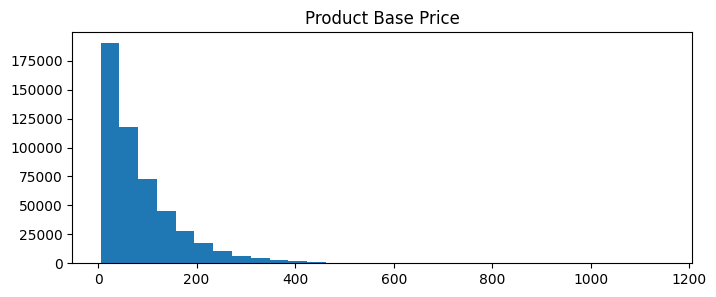

In [ ]:
plt.figure(figsize=(8,3))
plt.hist(df['product_base_price'], bins=30)
plt.title('Product Base Price')

print(df['product_base_price'].skew())

2.107808818591687


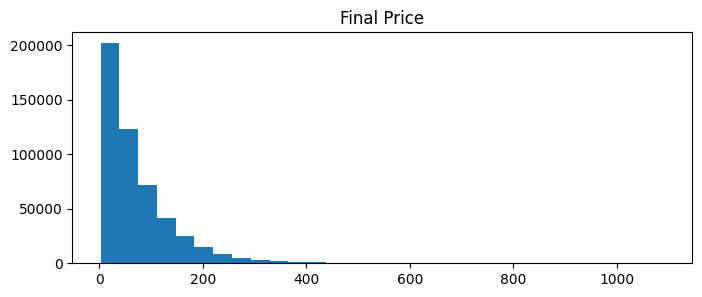

In [ ]:
plt.figure(figsize=(8,3))
plt.hist(df['final_price'], bins=30)
plt.title('Final Price')

print(df['final_price'].skew())

4.384067717924894


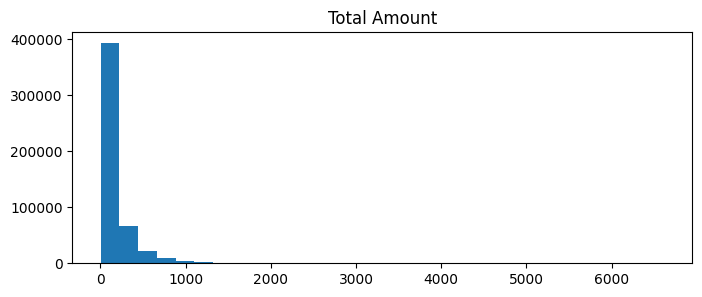

In [ ]:
plt.figure(figsize=(8,3))
plt.hist(df['total_amount'], bins=30)
plt.title('Total Amount')

print(df['total_amount'].skew())

## Phase 3
Which categorical columns will break your ML pipeline if left untouched?

EDA

In [ ]:
df.select_dtypes(include='object').columns

Index(['category', 'sub_category', 'shipping_method', 'payment_method',
       'customer_gender', 'country', 'city', 'loyalty_tier', 'return_reason'],
      dtype='object')

In [ ]:
df.select_dtypes(include='object').nunique()

,0
category,10
sub_category,45
shipping_method,4
payment_method,6
customer_gender,3
country,8
city,15
loyalty_tier,4
return_reason,5


<Axes: xlabel='category', ylabel='count'>

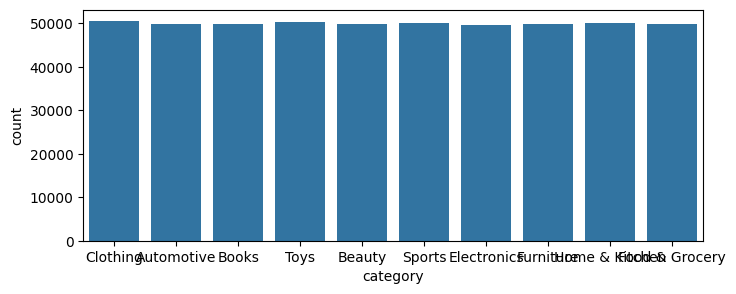

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='category')

<Axes: xlabel='shipping_method', ylabel='count'>

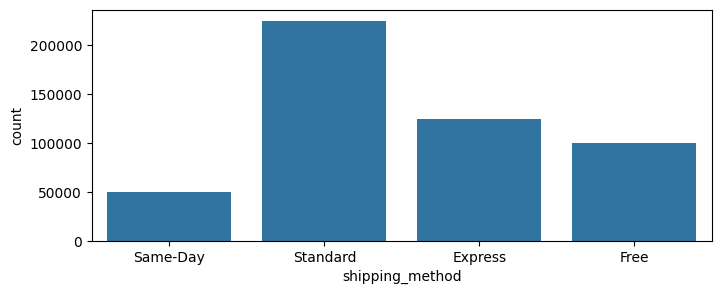

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='shipping_method')

<Axes: xlabel='payment_method', ylabel='count'>

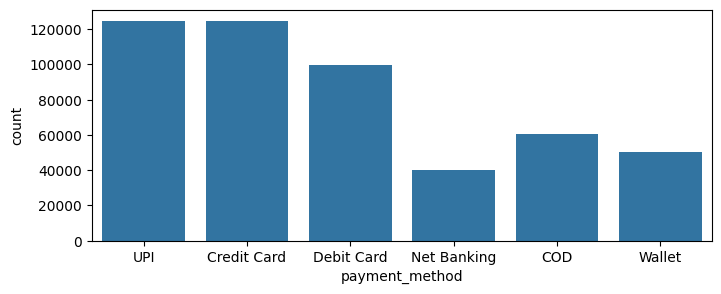

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='payment_method')

<Axes: xlabel='loyalty_tier', ylabel='count'>

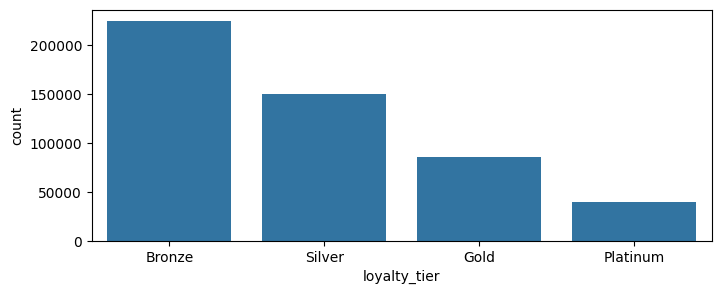

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='loyalty_tier')

<Axes: xlabel='customer_gender', ylabel='count'>

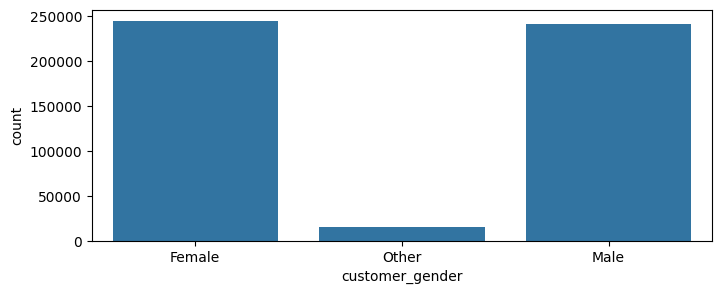

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='customer_gender')

<Axes: xlabel='city'>

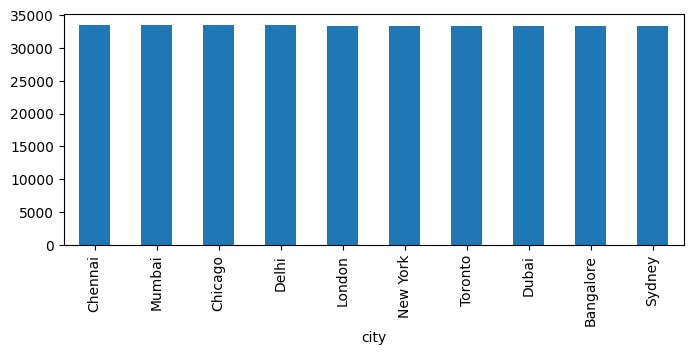

In [ ]:
plt.figure(figsize=(8,3))
df['city'].value_counts().head(10).plot(kind='bar')

<Axes: xlabel='sub_category'>

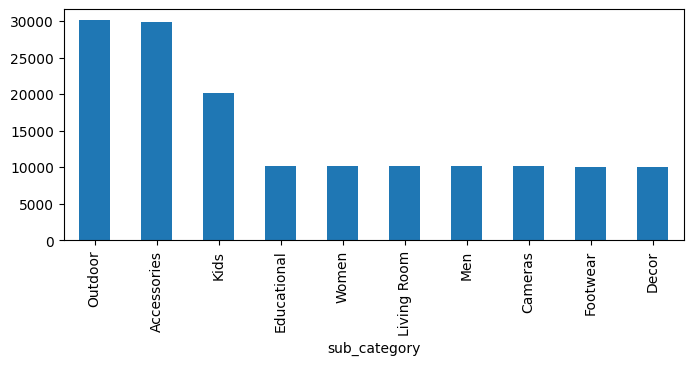

In [ ]:
plt.figure(figsize=(8,3))
df['sub_category'].value_counts().head(10).plot(kind='bar')

In [ ]:
df['loyalty_tier'].value_counts()

,count
loyalty_tier,
Bronze,225029
Silver,149932
Gold,85147
Platinum,39892


## Phase 4
Why are customers returning products? Find the patterns that matter to the business.

Scenario EDA


<Axes: xlabel='is_returned', ylabel='count'>

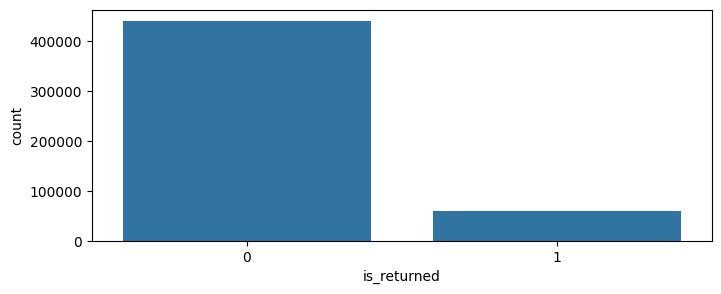

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='is_returned')

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Wrong Item'),
  Text(1, 0, 'Not as Described'),
  Text(2, 0, 'Changed Mind'),
  Text(3, 0, 'Better Price Found'),
  Text(4, 0, 'Defective')])

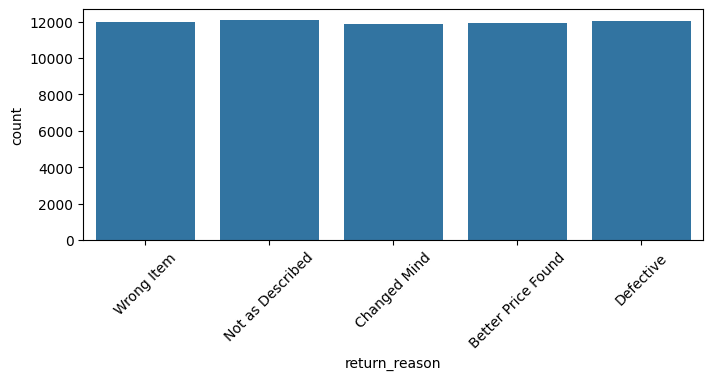

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(data=df[df['is_returned'] == 1], x='return_reason')
plt.xticks(rotation=45)

In [ ]:
pd.crosstab(df['category'], df['is_returned'])

is_returned,0,1
category,,
Automotive,43854,6007
Beauty,43909,6020
Books,43906,6011
Clothing,44616,5980
Electronics,43675,6020
Food & Grocery,43863,5943
Furniture,43877,6039
Home & Kitchen,44087,5952
Sports,44104,5937


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Clothing'),
  Text(1, 0, 'Automotive'),
  Text(2, 0, 'Books'),
  Text(3, 0, 'Toys'),
  Text(4, 0, 'Beauty'),
  Text(5, 0, 'Sports'),
  Text(6, 0, 'Electronics'),
  Text(7, 0, 'Furniture'),
  Text(8, 0, 'Home & Kitchen'),
  Text(9, 0, 'Food & Grocery')])

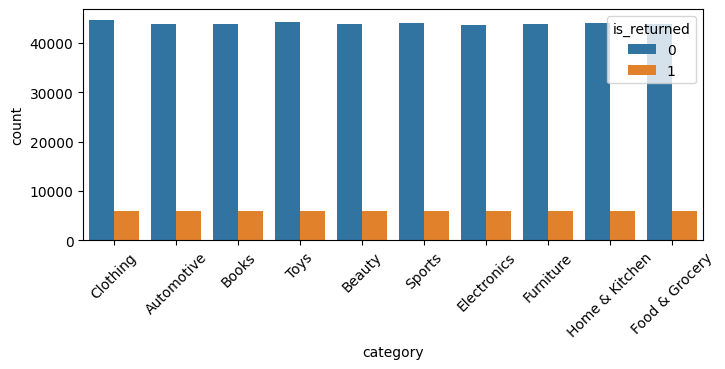

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='category', hue='is_returned')
plt.xticks(rotation=45)

In [ ]:
pd.crosstab(df['loyalty_tier'], df['is_returned'])

is_returned,0,1
loyalty_tier,,
Bronze,197961,27068
Gold,74944,10203
Platinum,35121,4771
Silver,132070,17862


<Axes: xlabel='loyalty_tier', ylabel='count'>

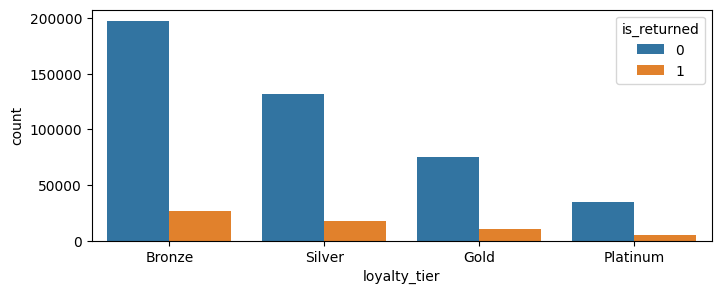

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='loyalty_tier', hue='is_returned')

In [ ]:
pd.crosstab(df['shipping_method'], df['is_returned'])

is_returned,0,1
shipping_method,,
Express,109792,14976
Free,87935,11955
Same-Day,44165,5949
Standard,198204,27024


<Axes: xlabel='shipping_method', ylabel='count'>

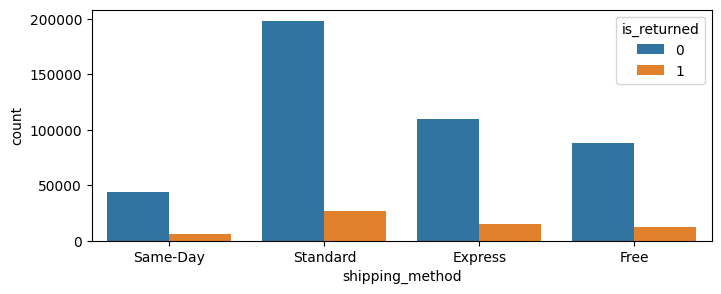

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='shipping_method', hue='is_returned')

In [ ]:
pd.crosstab(df['payment_method'], df['is_returned'])

is_returned,0,1
payment_method,,
COD,53103,7266
Credit Card,109874,14991
Debit Card,87843,11822
Net Banking,35363,4767
UPI,109910,15028
Wallet,44003,6030


<Axes: xlabel='payment_method', ylabel='count'>

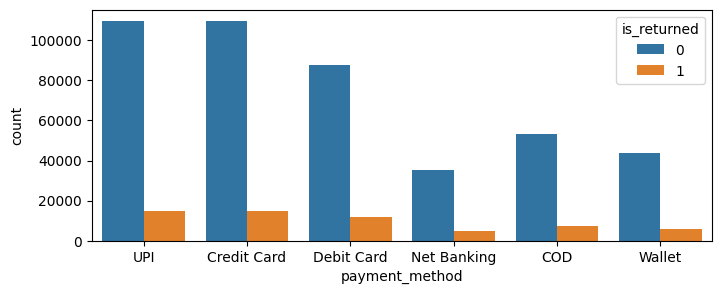

In [ ]:
plt.figure(figsize=(8,3))
sns.countplot(data=df, x='payment_method', hue='is_returned')

In [ ]:
df.groupby('is_returned')['days_to_deliver'].mean()

,days_to_deliver
is_returned,
0,4.237801
1,4.242337


In [ ]:
df.groupby('is_returned')['days_to_deliver'].mean()

,days_to_deliver
is_returned,
0,4.237801
1,4.242337


In [ ]:
df.groupby('is_returned')['rating'].mean()

,rating
is_returned,
0,3.797806
1,3.784849


<Axes: xlabel='is_returned', ylabel='rating'>

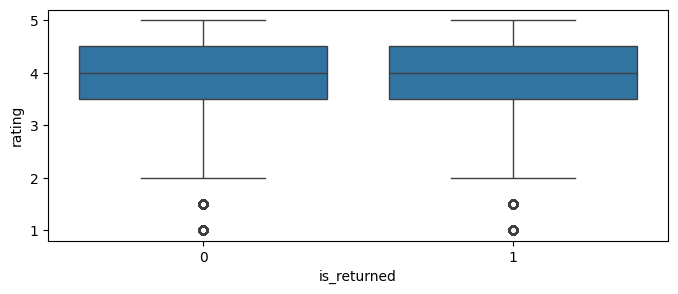

In [ ]:
plt.figure(figsize=(8,3))
sns.boxplot(data=df, x='is_returned', y='rating')

In [ ]:
df.groupby('is_returned')['discount_percentage'].mean()

,discount_percentage
is_returned,
0,14.586340
1,14.692758


<Axes: xlabel='is_returned', ylabel='discount_percentage'>

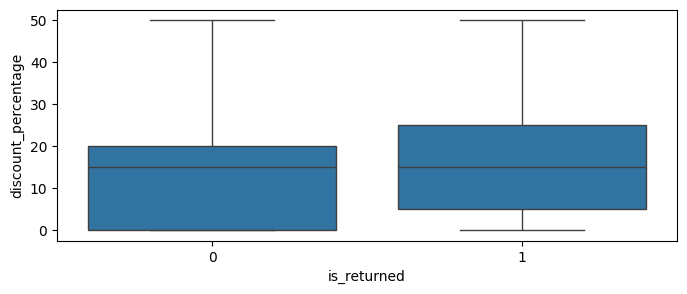

In [ ]:
plt.figure(figsize=(8,3))
sns.boxplot(data=df, x='is_returned', y='discount_percentage')

## Phase 5
Build the full ColumnTransformer pipeline — different scalers for different columns, handle missings,
encode categoricals.

Feature Engineering


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

In [ ]:
num1 = ['product_base_price','final_price','total_amount',
        'customer_lifetime_value','shipping_cost']

num2 = ['quantity','days_to_deliver','rating',
        'num_reviews','customer_age',
        'session_duration_mins','pages_viewed',
        'clicks_to_purchase']

cat = ['category','sub_category','shipping_method',
       'payment_method','customer_gender',
       'country','city']

ord = ['loyalty_tier']

In [ ]:
num_pipe1 = Pipeline([
    ('fill', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

num_pipe2 = Pipeline([
    ('fill', SimpleImputer(strategy='median')),
    ('scale', MinMaxScaler())
])

cat_pipe = Pipeline([
    ('fill', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

ord_pipe = Pipeline([
    ('fill', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(categories=[['Bronze','Silver','Gold','Platinum']]))
])

In [ ]:
preprocessor = ColumnTransformer([
    ('num1', num_pipe1, num1),
    ('num2', num_pipe2, num2),
    ('cat', cat_pipe, cat),
    ('ord', ord_pipe, ord)
])

In [ ]:
preprocessor

ColumnTransformer(transformers=[('num1',
                                 Pipeline(steps=[('fill',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['product_base_price', 'final_price',
                                  'total_amount', 'customer_lifetime_value',
                                  'shipping_cost']),
                                ('num2',
                                 Pipeline(steps=[('fill',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', MinMaxScaler())]),
                                 ['quantity', 'days_to_deliver', 'rati...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['category', 'sub_category', 'shipping_method',
                                  'payment_method', 'customer_gender',
                                  'country', 'city']),
                                ('ord',
                                 Pipeline(steps=[('fill',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OrdinalEncoder(categories=[['Bronze',
                                                                              'Silver',
                                                                              'Gold',
                                                                              'Platinum']]))]),
                                 ['loyalty_tier'])])

In [ ]:
x = df.drop('is_returned', axis=1)

x = preprocessor.fit_transform(x)

x.shape

(500000, 105)

In [ ]:
x = pd.DataFrame(x)

x.head()

,0
0,<Compressed Sparse Row sparse matrix of dtype ...
1,<Compressed Sparse Row sparse matrix of dtype ...
2,<Compressed Sparse Row sparse matrix of dtype ...
3,<Compressed Sparse Row sparse matrix of dtype ...
4,<Compressed Sparse Row sparse matrix of dtype ...


## Phase 6
Are any features too correlated with each other? Which ones actually predict returns?

<Axes: >

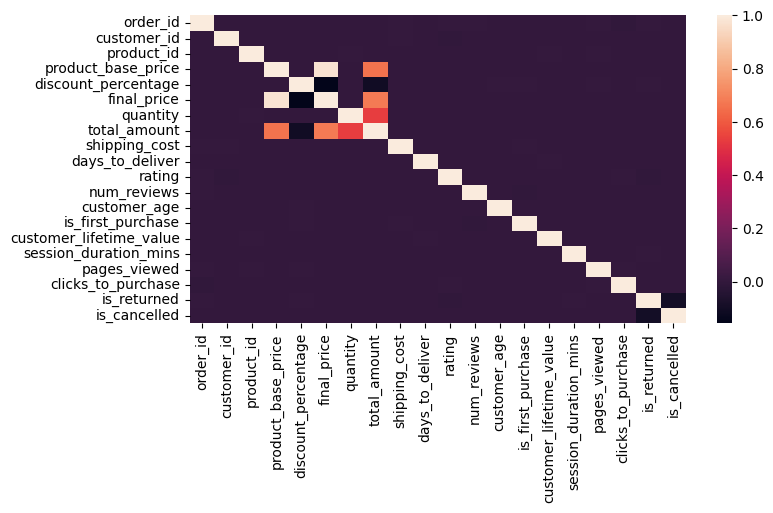

In [ ]:
num = df.select_dtypes(include=['int64','float64'])

corr = num.corr()

plt.figure(figsize=(8,4))
sns.heatmap(corr)

In [ ]:
corr['is_returned'].sort_values(ascending=False)

,is_returned
is_returned,1.000000
discount_percentage,0.002670
order_id,0.002068
session_duration_mins,0.002037
pages_viewed,0.001297
is_first_purchase,0.001002
days_to_deliver,0.000614
customer_lifetime_value,0.000235
quantity,-0.000420
customer_age,-0.000679


<Axes: >

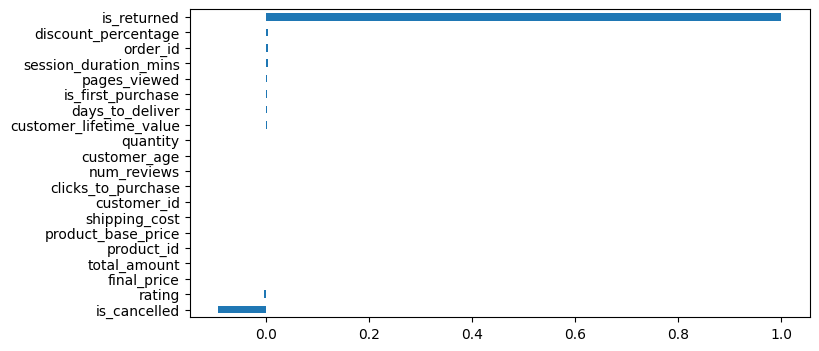

In [ ]:
corr['is_returned'].sort_values().plot(kind='barh', figsize=(8,4))

In [ ]:
corr

,order_id,customer_id,product_id,product_base_price,discount_percentage,final_price,quantity,total_amount,shipping_cost,days_to_deliver,rating,num_reviews,customer_age,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,is_cancelled
order_id,1.000000,0.000963,-0.002462,0.000106,0.000253,0.000464,-0.000233,-0.000390,0.001662,0.000943,0.002348,0.002816,0.000851,0.000233,-0.000150,0.000863,0.001711,-0.003346,0.002068,-0.001975
customer_id,0.000963,1.000000,-0.000662,-0.000887,-0.000880,-0.000832,-0.000508,-0.001924,0.002150,-0.001703,-0.003234,-0.001371,0.001057,-0.001450,-0.001861,-0.000500,0.000253,-0.002652,-0.001203,0.000985
product_id,-0.002462,-0.000662,1.000000,-0.001356,-0.001079,-0.001279,0.001955,0.001648,-0.000733,-0.000379,0.000160,-0.001269,-0.000155,0.001550,0.002291,-0.001823,0.001793,-0.002768,-0.001383,-0.000842
product_base_price,0.000106,-0.000887,-0.001356,1.000000,0.000941,0.976290,0.001358,0.659634,-0.000261,0.000029,-0.001029,-0.001120,-0.001906,-0.000112,-0.000907,-0.001186,-0.000289,0.001058,-0.001294,0.000382
discount_percentage,0.000253,-0.000880,-0.001079,0.000941,1.000000,-0.156454,0.000897,-0.104974,-0.001303,-0.001524,-0.002359,0.000566,0.002561,0.001693,-0.001453,0.000752,0.001883,-0.001003,0.002670,-0.000228
final_price,0.000464,-0.000832,-0.001279,0.976290,-0.156454,1.000000,0.001233,0.675412,-0.000351,0.000094,-0.000447,-0.001103,-0.002095,-0.000619,-0.000814,-0.000793,-0.000272,0.001084,-0.001599,0.000235
quantity,-0.000233,-0.000508,0.001955,0.001358,0.000897,0.001233,1.000000,0.531041,0.000039,-0.001228,-0.002726,-0.000632,-0.000216,-0.001843,0.000820,-0.000040,-0.000018,0.000192,-0.000420,0.000590
total_amount,-0.000390,-0.001924,0.001648,0.659634,-0.104974,0.675412,0.531041,1.000000,-0.000271,-0.000715,-0.002282,-0.001184,-0.000207,-0.000950,-0.001208,-0.001255,-0.000217,0.000415,-0.001512,0.000699
shipping_cost,0.001662,0.002150,-0.000733,-0.000261,-0.001303,-0.000351,0.000039,-0.000271,1.000000,-0.001904,-0.000400,-0.000477,-0.000093,0.002229,-0.001088,-0.000177,-0.000186,-0.001563,-0.001265,-0.001660
days_to_deliver,0.000943,-0.001703,-0.000379,0.000029,-0.001524,0.000094,-0.001228,-0.000715,-0.001904,1.000000,-0.000714,-0.001165,0.001321,-0.001149,0.002084,-0.001014,-0.000657,0.000188,0.000614,-0.001146


In [ ]:
# Homework C